In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.shape

(2240, 22)

In [7]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

In [8]:
#Handle missing values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [9]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [10]:
#Deriving age from the year_data.

df["Age"] = 2026 - df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
#Second thing we are deriving is the tenure of the  cutomer.

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date = df["Dt_Customer"].max()

df["customer_tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days'],
      dtype='object')

In [13]:
#Total Spending

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days',
       'Total_spending'],
      dtype='object')

In [14]:
#Total Childern

df["Total_Children"] = df["Teenhome"] + df["Kidhome"]

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_spending',
       'Total_Children'],
      dtype='object')

In [15]:
#Education 

df["Education"] = df["Education"].replace({
    "Graduation":"Graduate" , "PhD": "PostGraduate",
    "Master" : "PostGraduate" , "2nd Cycle" : "UnderGraduate",
    "Basic" : "UnderGraduate" })

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_spending',
       'Total_Children'],
      dtype='object')

In [60]:
#Marital Status

df["Living_with"] = df["Marital_Status"].replace({
     "Single":"Alone" , "Divorce": "Alone", "Widow" : "Alone",
    "Absurd" : "Alone" , "YOLO" : "Alone",
    "Married" : "Partner", "Together" : "Partner" })

df["Living_with"].head()

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_spending',
       'Total_Children', 'Living_with'],
      dtype='object')

# Drop Columns

In [61]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,Total_Children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [62]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outlier Detection

In [63]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'customer_tenure_days', 'Total_spending', 'Total_Children',
       'Living_with'],
      dtype='object')

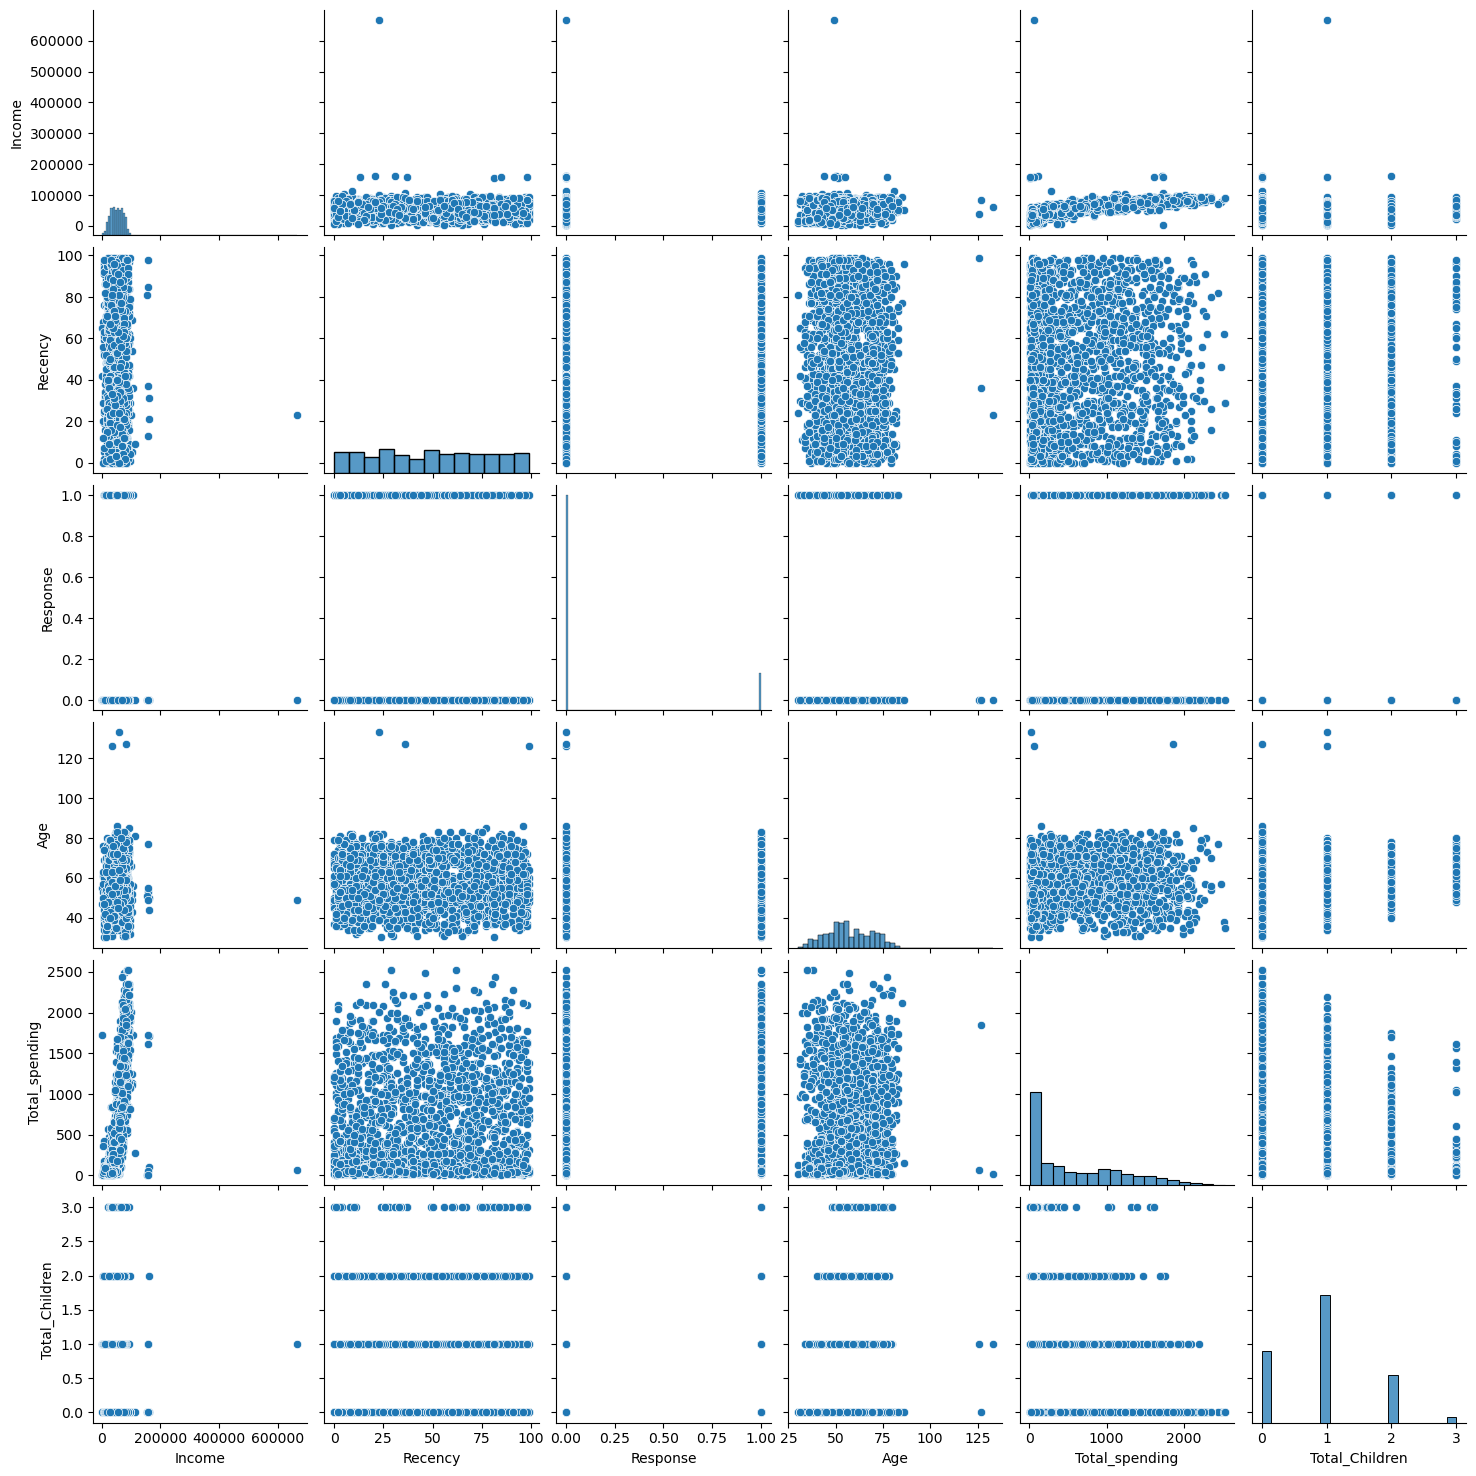

In [64]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_Children"]

# relative plots of some features-  pair plots

sns.pairplot(df_cleaned[cols])

In [66]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2236
data size without outliers: 2236


# HeatMap

In [67]:
corr = df_cleaned.corr(numeric_only="True")

<Axes: >

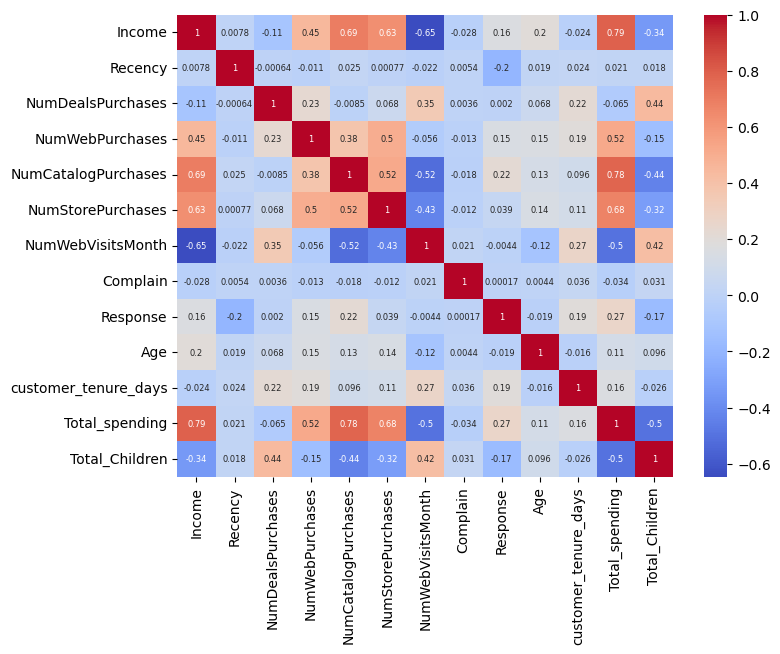

In [68]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [69]:
df_cleaned.shape

(2236, 15)

In [70]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding

In [71]:
from sklearn.preprocessing import OneHotEncoder

In [72]:
ohe = OneHotEncoder()

categorical_cols = ["Education", "Living_with"]

encoded_cat_cols = ohe.fit_transform(df_cleaned[categorical_cols])

In [73]:
encoded_df = pd.DataFrame(encoded_cat_cols.toarray(), columns=ohe.get_feature_names_out(categorical_cols), index=df_cleaned.index )

In [74]:
df_encoded= pd.concat([df_cleaned.drop(columns = categorical_cols),encoded_df], axis=1 )

In [76]:
df_encoded.shape

(2236, 20)

In [77]:
df_encoded.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_spending',
       'Total_Children', 'Education_2n Cycle', 'Education_Graduate',
       'Education_PostGraduate', 'Education_UnderGraduate',
       'Living_with_Alone', 'Living_with_Divorced', 'Living_with_Partner'],
      dtype='object')

In [51]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,...,Total_spending,Total_Children,Education_2n Cycle,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Divorced,Living_with_Partner,Living_with_Partnner
0,58138.0,58,3,8,10,4,7,0,1,69,...,1617,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,...,27,2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,...,776,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,...,53,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,...,422,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


# Scaling

In [78]:
from sklearn.preprocessing import StandardScaler

In [79]:
X = df_encoded

In [81]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualise Data

In [82]:
X_scaled.shape

(2236, 20)

In [83]:
from sklearn.decomposition import PCA

In [103]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d-projection')

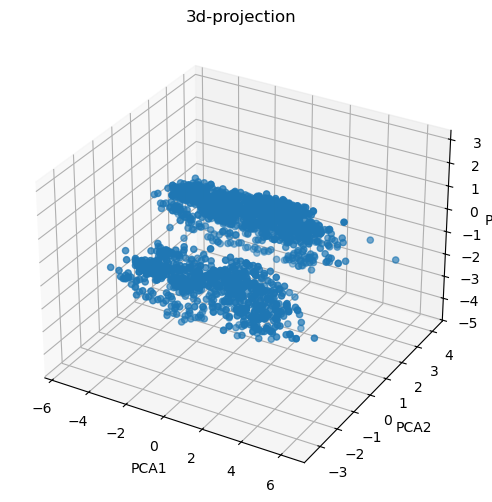

In [104]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d-projection")

## Analysing K Value

# 1. Elbow Method

In [113]:
from sklearn.cluster import KMeans

In [114]:
!pip install kneed

In [115]:
from kneed  import KneeLocator

In [119]:
#within clusters sum of squares (wcss)

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [122]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [123]:
print("best k :", optimal_k)

best k : 4


Text(0, 0.5, 'wcss')

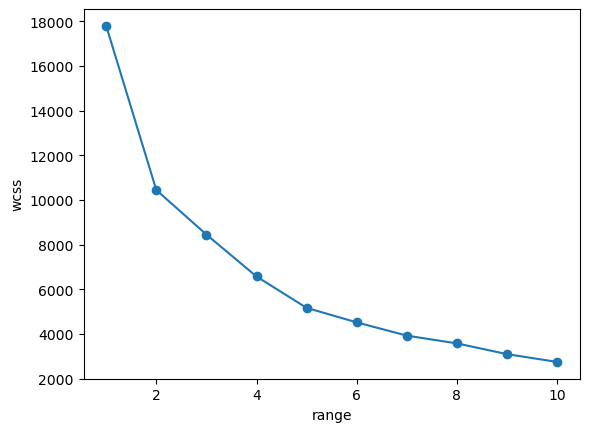

In [127]:
plt.plot(range(1,11), wcss , marker='o')
plt.xlabel("range")
plt.ylabel("wcss")

## 2. Silhouette Score

In [128]:
from sklearn.metrics import silhouette_score

Text(0, 0.5, 'scores')

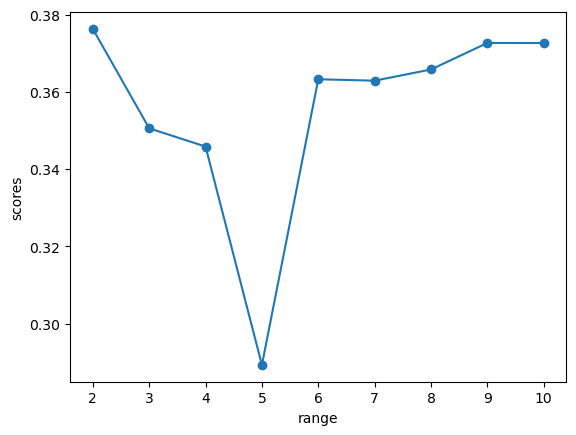

In [131]:
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plotting

plt.plot(range(2,11), scores , marker='o')
plt.xlabel("range")
plt.ylabel("scores")

Text(0, 0.5, 'SS')

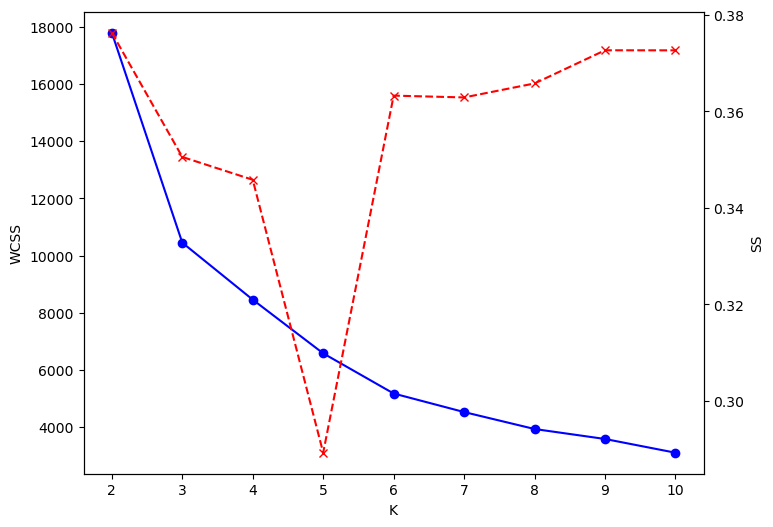

In [132]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

In [133]:
kmeans = KMeans(n_clusters=4 , random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

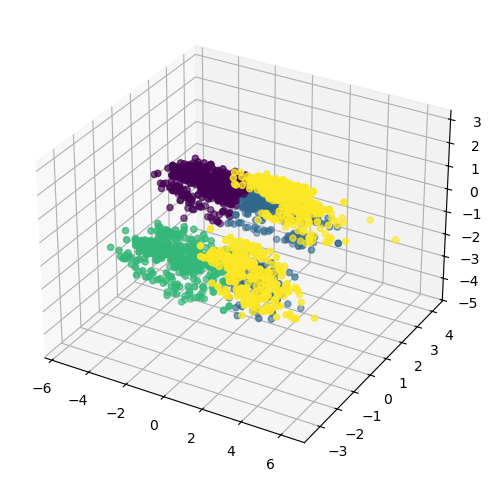

In [137]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2], c=labels_kmeans)

In [142]:
# Agglomerative Clustering


from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters = 4, linkage='ward')

agg_labels = agg_clf.fit_predict(X_pca)

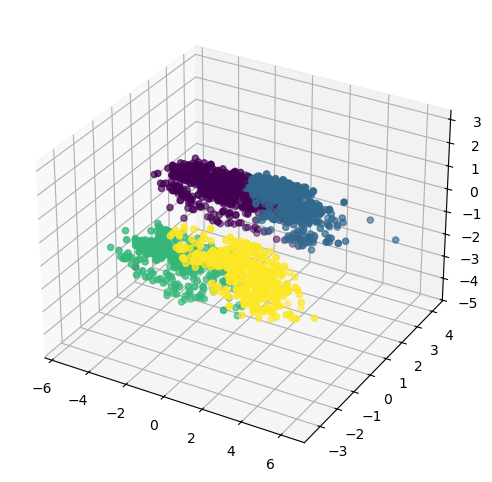

In [145]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=agg_labels)

# Characterization of clusters

In [146]:
X["Cluster"] = agg_labels

In [147]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,...,Total_spending,Total_Children,Education_2n Cycle,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Divorced,Living_with_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,...,1617,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,...,27,2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,...,776,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,...,53,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,...,422,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0


<Axes: xlabel='Cluster', ylabel='count'>

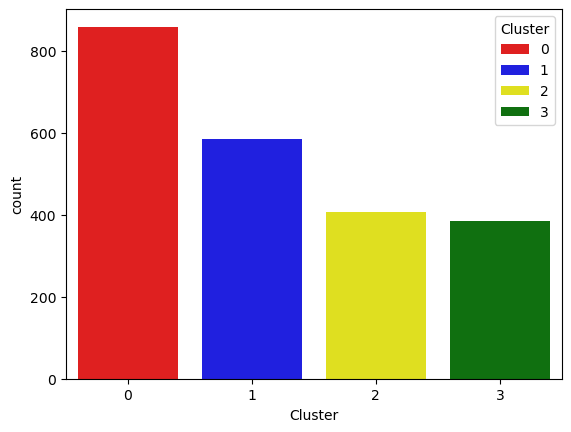

In [149]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["Cluster"], palette=pal, hue=X["Cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

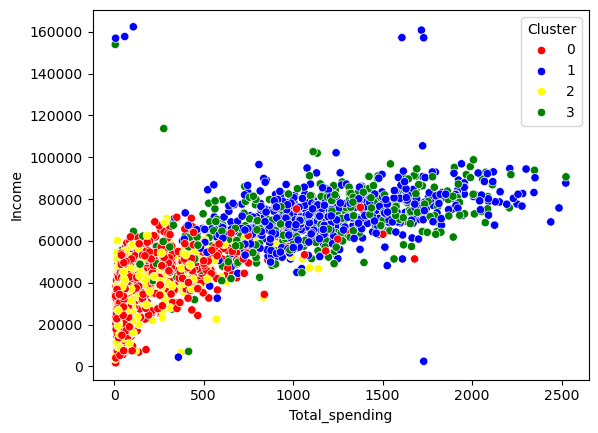

In [152]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["Cluster"], palette=pal)

In [155]:
# Cluster Summary

cluster_summary = X.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        38262.921420  49.287544           2.658906         2.932480   
1        71707.776923  48.724786           1.976068         5.765812   
2        36394.317734  47.539409           2.546798         2.682266   
3        68842.106218  50.987047           1.883420         5.593264   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.862631           3.912689           6.511059  0.009313   
1                   5.252991           8.570940           3.632479  0.008547   
2                   0.785714           3.576355           6.650246  0.012315   
3                   4.720207           8.113990           3.821244  0.005181   

         Response        Age  customer_tenure_days  Total_spending  \
Cluster         